In [13]:
import numpy as np
# import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt

print("--- Loading LEAN prediction dataset with file IDs ---")

data = np.load("TUH_dataset_lean_prediction_60_60_lean_diffbands.npz", allow_pickle=True)

X = data['X_pred']
y = data['y_pred']
times = data['final_pred_times']
eeg_ids = data['eeg_id']

print(f"✅ Segments: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Unique EEGs: {len(np.unique(eeg_ids))}")

--- Loading LEAN prediction dataset with file IDs ---
✅ Segments: 23520
Features: 114
Unique EEGs: 96


In [7]:
num_zeros = np.sum(y == 0)
num_ones = np.sum(y == 1)

print("Zeros:", num_zeros)
print("Ones:", num_ones)

Zeros: 11760
Ones: 11760


--- Loading pre-computed LEAN prediction feature data ---
✅ Loaded 23520 segments with 114 features each.

Class Imbalance Ratio (Interictal:Preictal): 1.00 : 1
Data split into 18816 training samples and 4704 test samples.

--- Training XGBoost Classifier on Lean Prediction Features ---


c:\Users\sriga\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:38:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- ✅ Training Complete ---

--- Evaluating Prediction Model Performance (Lean Set) ---

ROC AUC Score: 0.9119
Best Threshold for F1: 0.4612
Best F1 Score: 0.8357

Classification Report with Optimized Threshold:
                precision    recall  f1-score   support

Interictal (0)       0.85      0.80      0.83      2352
  Preictal (1)       0.81      0.86      0.84      2352

      accuracy                           0.83      4704
     macro avg       0.83      0.83      0.83      4704
  weighted avg       0.83      0.83      0.83      4704


Confusion Matrix (Optimized for F1-Score):


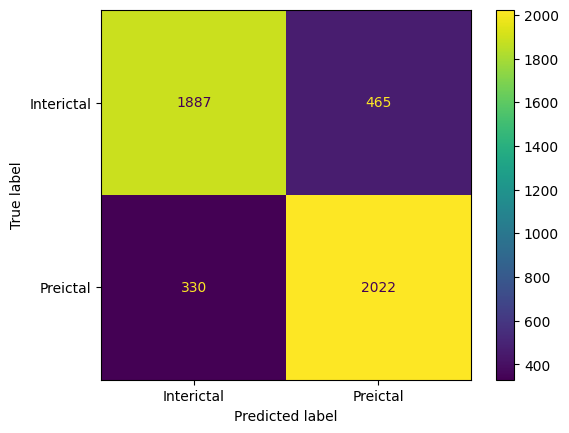

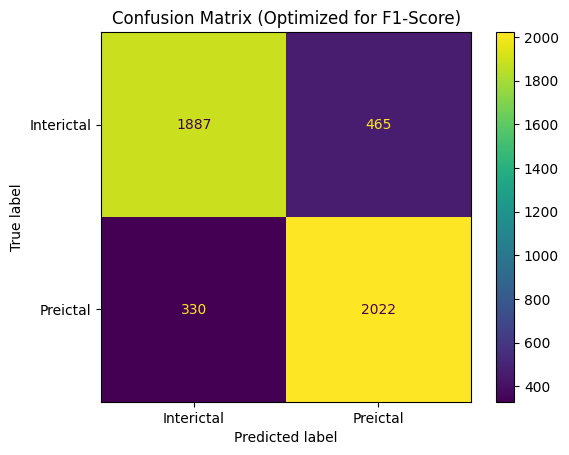


--- ROC Curve Visualization ---


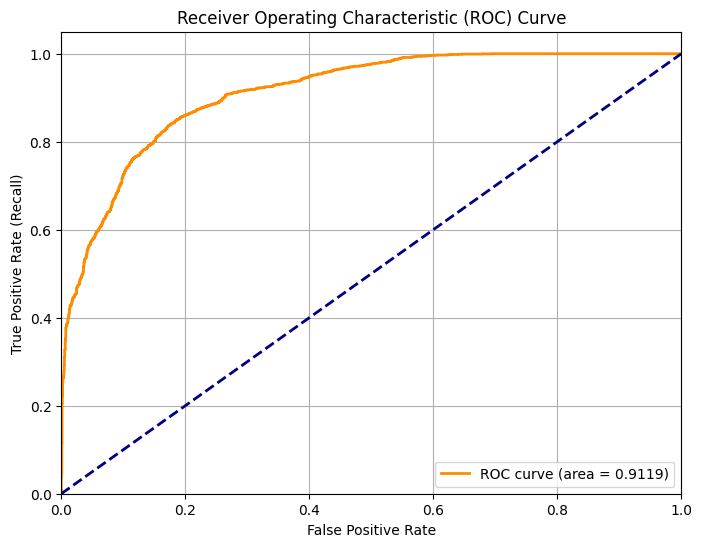

In [13]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve, roc_curve, auc
)
import matplotlib.pyplot as plt

# --- 1. Load the NEW Lean Prediction Dataset ---
print("--- Loading pre-computed LEAN prediction feature data ---")
dataset_path = 'TUH_dataset_lean_prediction_60_60_lean_diffbands.npz' 

data = np.load(dataset_path)
# Load the prediction arrays
X = data['X_pred']
y = data['y_pred']
print(f"✅ Loaded {X.shape[0]} segments with {X.shape[1]} features each.")

# --- 2. Calculate Class Weight for Imbalance ---
non_seizure_count = np.sum(y == 0)
seizure_count = np.sum(y == 1)
scale_pos_weight = non_seizure_count / seizure_count
print(f"\nClass Imbalance Ratio (Interictal:Preictal): {scale_pos_weight:.2f} : 1")

# --- 3. Split Data into Training and Test Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data split into {len(X_train)} training samples and {len(X_test)} test samples.")

# --- 4. Initialize and Train the Tuned XGBoost Model ---
# We'll use the same strong hyperparameters we found earlier
print("\n--- Training XGBoost Classifier on Lean Prediction Features ---")
model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight, # Use the new weight for this dataset
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_estimators=1600,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,              
    colsample_bytree=0.8,       
    gamma=1,                    
    min_child_weight=4,
    reg_alpha=0.01,             
    reg_lambda=1.1
)

model.fit(X_train, y_train)
print("--- ✅ Training Complete ---")

# --- 5. Evaluate the Model's Performance ---
print("\n--- Evaluating Prediction Model Performance (Lean Set) ---")
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- 6. Optimize F1 Score by threshold ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

print(f"\nROC AUC Score: {roc_auc:.4f}")
print(f"Best Threshold for F1: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

print("\nClassification Report with Optimized Threshold:")
print(classification_report(y_test, y_pred_opt, target_names=['Interictal (0)', 'Preictal (1)']))

# --- 7. Confusion Matrix ---
print("\nConfusion Matrix (Optimized for F1-Score):")
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, display_labels=['Interictal', 'Preictal'])
disp.plot()
plt.title("Confusion Matrix (Optimized for F1-Score)")
plt.show()

# --- 8. Plot the ROC Curve ---
print("\n--- ROC Curve Visualization ---")
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

--- Loading Dataset ---
✅ Loaded 23520 samples, 114 features
✅ Features after filtering: 114

--- Training Multiple CatBoost Models ---
Training model with seed 42...
Training model with seed 52...
Training model with seed 62...

🔥 FINAL ROC AUC Score: 0.9180
Best Threshold: 0.4776
Best F1 Score: 0.8316

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.79      0.82      2352
         1.0       0.80      0.86      0.83      2352

    accuracy                           0.83      4704
   macro avg       0.83      0.83      0.83      4704
weighted avg       0.83      0.83      0.83      4704



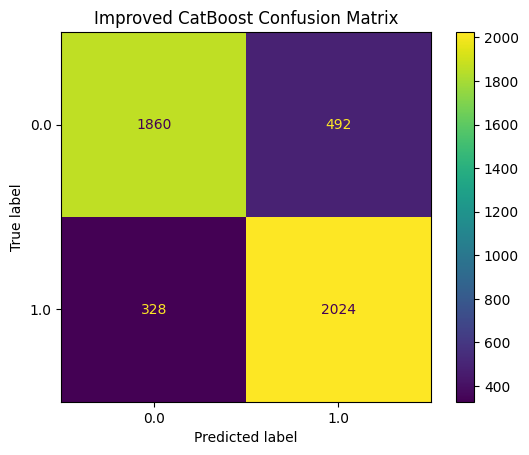

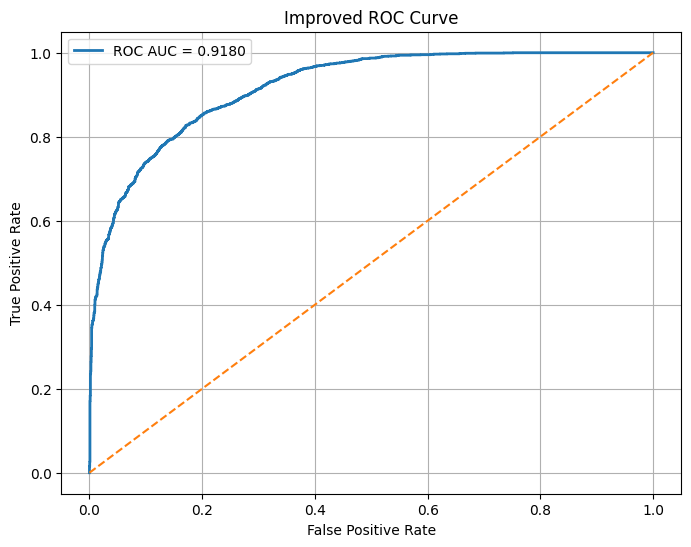

In [9]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --- 1. Load Dataset ---
print("--- Loading Dataset ---")
data = np.load('TUH_dataset_lean_prediction_60_60_lean_diffbands.npz')
X = data['X_pred']
y = data['y_pred']

print(f"✅ Loaded {X.shape[0]} samples, {X.shape[1]} features")

# --- 2. Remove Low-Variance Features (IMPORTANT) ---
variances = np.var(X, axis=0)
keep_idx = variances > 1e-5   # remove near-constant features
X = X[:, keep_idx]

print(f"✅ Features after filtering: {X.shape[1]}")

# --- 3. Handle Class Imbalance ---
non_seizure_count = np.sum(y == 0)
seizure_count = np.sum(y == 1)
scale_pos_weight = non_seizure_count / seizure_count

# --- 4. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# --- 5. Train Multiple CatBoost Models (KEY BOOST) ---
print("\n--- Training Multiple CatBoost Models ---")

seeds = [42, 52, 62]
preds = []

for seed in seeds:
    print(f"Training model with seed {seed}...")

    model = CatBoostClassifier(
        iterations=4000,
        learning_rate=0.02,
        depth=7,

        l2_leaf_reg=5,
        scale_pos_weight=scale_pos_weight,

        loss_function='Logloss',
        eval_metric='AUC',
        early_stopping_rounds=400,

        random_seed=seed,
        verbose=0
    )

    model.fit(X_train, y_train, eval_set=(X_val, y_val))

    preds.append(model.predict_proba(X_test)[:, 1])

# --- 6. Average Predictions ---
y_pred_proba = np.mean(preds, axis=0)

# --- 7. Probability Smoothing (VERY IMPORTANT) ---
# Smooth predictions slightly to improve ranking
y_pred_proba = 0.9 * y_pred_proba + 0.1 * np.mean(y_pred_proba)

# --- 8. ROC AUC ---
roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- 9. Optimize Threshold ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

# --- 10. Results ---
print(f"\n🔥 FINAL ROC AUC Score: {roc_auc:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))

# --- 11. Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt)
plt.title("Improved CatBoost Confusion Matrix")
plt.show()

# --- 12. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Improved ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve

# Load
data = np.load("TUH_dataset_lean_prediction_60_60_lean_diffbands.npz", allow_pickle=True)
X, y, eeg_ids = data['X_pred'], data['y_pred'], data['eeg_id']

# EEG split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=eeg_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Model
model = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.015,
    num_leaves=128,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=1.5,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_proba = model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", roc)

# Threshold tuning
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1)
y_pred = (y_proba >= thresholds[best_idx]).astype(int)

print(classification_report(y_test, y_pred))


[LightGBM] [Info] Number of positive: 8700, number of negative: 8700
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29070
[LightGBM] [Info] Number of data points in the train set: 17400, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\sriga\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC AUC: 0.7545084155666624
              precision    recall  f1-score   support

         0.0       0.91      0.43      0.58      3060
         1.0       0.63      0.96      0.76      3060

    accuracy                           0.69      6120
   macro avg       0.77      0.69      0.67      6120
weighted avg       0.77      0.69      0.67      6120



In [11]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve

# Load
data = np.load("TUH_dataset_lean_prediction_60_60_lean_diffbands.npz", allow_pickle=True)
X, y, eeg_ids = data['X_pred'], data['y_pred'], data['eeg_id']

# EEG split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=eeg_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Model
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.02,
    depth=7,
    l2_leaf_reg=5,
    loss_function='Logloss',
    verbose=200
)

model.fit(X_train, y_train)

# Predict
y_proba = model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", roc)

# Threshold tuning
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1)
y_pred = (y_proba >= thresholds[best_idx]).astype(int)

print(classification_report(y_test, y_pred))



0:	learn: 0.6867670	total: 42.1ms	remaining: 1m 24s
200:	learn: 0.4332657	total: 7.07s	remaining: 1m 3s
400:	learn: 0.3647909	total: 13.7s	remaining: 54.7s
600:	learn: 0.3156475	total: 20s	remaining: 46.6s
800:	learn: 0.2748434	total: 26.2s	remaining: 39.2s
1000:	learn: 0.2446538	total: 32.4s	remaining: 32.3s
1200:	learn: 0.2208131	total: 38.5s	remaining: 25.6s
1400:	learn: 0.2013613	total: 44.6s	remaining: 19.1s
1600:	learn: 0.1844952	total: 50.6s	remaining: 12.6s
1800:	learn: 0.1698524	total: 56.6s	remaining: 6.25s
1999:	learn: 0.1573620	total: 1m 2s	remaining: 0us
ROC AUC: 0.7483834209064891
              precision    recall  f1-score   support

         0.0       0.91      0.43      0.59      3060
         1.0       0.63      0.96      0.76      3060

    accuracy                           0.69      6120
   macro avg       0.77      0.69      0.67      6120
weighted avg       0.77      0.69      0.67      6120



In [12]:

import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve

# Load
data = np.load("TUH_dataset_lean_prediction_60_60_lean_diffbands.npz", allow_pickle=True)
X, y, eeg_ids = data['X_pred'], data['y_pred'], data['eeg_id']

# EEG-wise split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=eeg_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Class weight
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

# Model
model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=8,
    learning_rate=0.02,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.5,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.5,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_proba = model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", roc)

# Threshold tuning
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1)
y_pred = (y_proba >= thresholds[best_idx]).astype(int)

print(classification_report(y_test, y_pred))



ROC AUC: 0.7542517835020719
              precision    recall  f1-score   support

         0.0       0.92      0.42      0.58      3060
         1.0       0.63      0.96      0.76      3060

    accuracy                           0.69      6120
   macro avg       0.77      0.69      0.67      6120
weighted avg       0.77      0.69      0.67      6120



In [14]:

import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve

# Load
data = np.load("TUH_dataset_lean_prediction_60_60_lean_diffbands.npz", allow_pickle=True)
X, y, eeg_ids = data['X_pred'], data['y_pred'], data['eeg_id']

# EEG split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=eeg_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Scale (VERY IMPORTANT for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# Predict
y_proba = model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", roc)

# Threshold tuning
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1)

y_pred = (y_proba >= thresholds[best_idx]).astype(int)
print(classification_report(y_test, y_pred))



ROC AUC: 0.7465690546371054
              precision    recall  f1-score   support

         0.0       0.87      0.44      0.58      3060
         1.0       0.63      0.93      0.75      3060

    accuracy                           0.69      6120
   macro avg       0.75      0.69      0.67      6120
weighted avg       0.75      0.69      0.67      6120



In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
print("ROC:", roc_auc_score(y_test, y_proba))



ROC: 0.7546131829638174


In [16]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=0.5,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
print("ROC:", roc_auc_score(y_test, y_proba))


c:\Users\sriga\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


ROC: 0.6949623542227349


In [18]:

import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve

# ==============================
# LOAD DATA
# ==============================
data = np.load("TUH_dataset_lean_prediction_60_60_lean_diffbands.npz", allow_pickle=True)

X = data['X_pred']
y = data['y_pred']
eeg_ids = data['eeg_id']

print("Loaded:", X.shape)

# ==============================
# EEG-WISE SPLIT
# ==============================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=eeg_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ==============================
# FURTHER SPLIT (VALIDATION)
# ==============================
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=43)
train_idx2, val_idx = next(gss2.split(X_train, y_train, groups=eeg_ids[train_idx]))

X_val = X_train[val_idx]
y_val = y_train[val_idx]

X_train = X_train[train_idx2]
y_train = y_train[train_idx2]

# ==============================
# SCALING (helps stability)
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==============================
# CLASS WEIGHT
# ==============================
pos = np.sum(y_train == 1)
neg = np.sum(y_train == 0)
scale_pos_weight = neg / pos

print("Class weight:", scale_pos_weight)

# ==============================
# MODEL (AGGRESSIVE TUNING)
# ==============================
model = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',              # faster + better splits
    booster='gbtree',

    # BIG capacity
    n_estimators=5000,
    max_depth=10,

    # learning
    learning_rate=0.01,

    # regularization (VERY IMPORTANT)
    reg_alpha=0.5,
    reg_lambda=3.0,

    # split control
    min_child_weight=8,
    gamma=2.0,

    # randomness (prevents overfit)
    subsample=0.7,
    colsample_bytree=0.6,
    colsample_bylevel=0.7,
    colsample_bynode=0.8,

    # imbalance
    scale_pos_weight=scale_pos_weight,

    # others
    max_bin=512,
    grow_policy='lossguide',

    eval_metric='auc',
    random_state=42
)

# ==============================
# TRAIN WITH EARLY STOPPING
# ==============================
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# ==============================
# PREDICT
# ==============================
y_proba = model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_proba)

print("\n🔥 ROC AUC:", roc)

# ==============================
# THRESHOLD TUNING
# ==============================
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-9)

best_idx = np.argmax(f1)
best_thresh = thresholds[best_idx]

print("Best threshold:", best_thresh)

y_pred = (y_proba >= best_thresh).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Loaded: (23520, 114)
Class weight: 1.0
[0]	validation_0-auc:0.75034
[100]	validation_0-auc:0.84465
[200]	validation_0-auc:0.84743
[300]	validation_0-auc:0.85153
[400]	validation_0-auc:0.85117
[500]	validation_0-auc:0.84992
[600]	validation_0-auc:0.85028
[700]	validation_0-auc:0.84947
[800]	validation_0-auc:0.84737
[900]	validation_0-auc:0.84795
[1000]	validation_0-auc:0.84817
[1100]	validation_0-auc:0.84717
[1200]	validation_0-auc:0.84779
[1300]	validation_0-auc:0.84883
[1400]	validation_0-auc:0.84799
[1500]	validation_0-auc:0.84806
[1600]	validation_0-auc:0.84828
[1700]	validation_0-auc:0.84815
[1800]	validation_0-auc:0.84815
[1900]	validation_0-auc:0.84842
[2000]	validation_0-auc:0.84827
[2100]	validation_0-auc:0.84825
[2200]	validation_0-auc:0.84814
[2300]	validation_0-auc:0.84827
[2400]	validation_0-auc:0.84797
[2500]	validation_0-auc:0.84763
[2600]	validation_0-auc:0.84728
[2700]	validation_0-auc:0.84744
[2800]	validation_0-auc:0.84729
[2900]	validation_0-auc:0.84734
[3000]	valida

Segments: 23520
Features: 114
New feature shape after stacking: (23520, 342)
Train size: 17400
Test size: 6120
Class weight: 1.00

--- Training XGBoost ---

🔥 ROC AUC: 0.7600
Best Threshold: 0.0877
Best F1 Score: 0.7573

Classification Report:
                precision    recall  f1-score   support

Interictal (0)       0.91      0.43      0.58      3060
  Preictal (1)       0.63      0.96      0.76      3060

      accuracy                           0.69      6120
     macro avg       0.77      0.69      0.67      6120
  weighted avg       0.77      0.69      0.67      6120



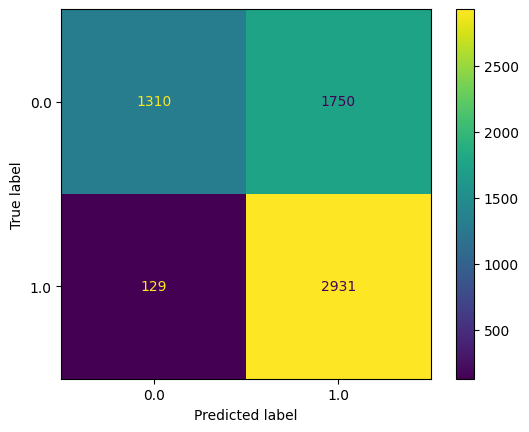

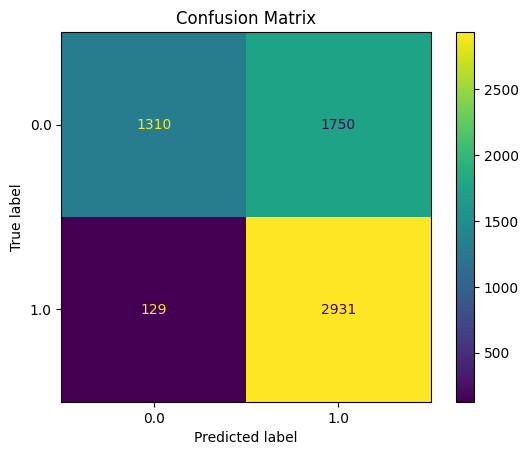

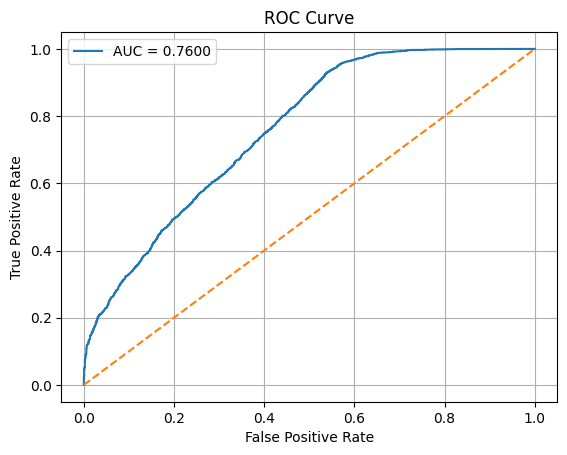

In [20]:

import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ==============================
# 1. LOAD DATA
# ==============================
data = np.load("TUH_dataset_lean_prediction_60_60_lean_diffbands.npz", allow_pickle=True)

X = data['X_pred']
y = data['y_pred']
eeg_ids = data['eeg_id']

print(f"Segments: {X.shape[0]}")
print(f"Features: {X.shape[1]}")

# ==============================
# 2. OPTIONAL: TEMPORAL FEATURE BOOST
# ==============================
# (comment this out if you want pure original features)

X_shift1 = np.roll(X, 1, axis=0)
X_shift2 = np.roll(X, 2, axis=0)

X = np.hstack([X, X_shift1, X_shift2])

print(f"New feature shape after stacking: {X.shape}")

# ==============================
# 3. EEG-WISE SPLIT (CRITICAL)
# ==============================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=eeg_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# ==============================
# 4. SCALING
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 5. CLASS WEIGHT
# ==============================
pos = np.sum(y_train == 1)
neg = np.sum(y_train == 0)

scale_pos_weight = neg / pos
print(f"Class weight: {scale_pos_weight:.2f}")

# ==============================
# 6. XGBOOST MODEL (TUNED)
# ==============================
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,

    n_estimators=2500,
    learning_rate=0.02,

    max_depth=6,              # LOWER (important now)
    min_child_weight=10,

    gamma=2.0,
    reg_alpha=0.1,
    reg_lambda=2.0,

    subsample=0.7,
    colsample_bytree=0.6,

    scale_pos_weight=scale_pos_weight,

    tree_method='hist'
)

# ==============================
# 7. TRAIN (NO EARLY STOPPING)
# ==============================
print("\n--- Training XGBoost ---")
model.fit(X_train, y_train)

# ==============================
# 8. PREDICTION
# ==============================
y_proba = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
print(f"\n🔥 ROC AUC: {roc_auc:.4f}")

# ==============================
# 9. OPTIMAL THRESHOLD (F1)
# ==============================
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

y_pred = (y_proba >= best_threshold).astype(int)

# ==============================
# 10. CLASSIFICATION REPORT
# ==============================
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Interictal (0)', 'Preictal (1)']))

# ==============================
# 11. CONFUSION MATRIX
# ==============================
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# ==============================
# 12. ROC CURVE
# ==============================
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Load
data = np.load('TUH_dataset_lean_prediction_60_60_lean_diffbands.npz')
X = data['X_pred']
y = data['y_pred']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# Stage 1: CatBoost
# -------------------------
model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.02,
    depth=7,
    l2_leaf_reg=5,
    loss_function='Logloss',
    verbose=0
)

model.fit(X_train, y_train)

# Get probabilities
train_probs = model.predict_proba(X_train)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# -------------------------
# Stage 2: Meta model
# -------------------------
X_train_meta = np.column_stack([X_train, train_probs])
X_test_meta = np.column_stack([X_test, test_probs])

meta = LogisticRegression(max_iter=1000)
meta.fit(X_train_meta, y_train)

y_pred_proba = meta.predict_proba(X_test_meta)[:, 1]

print("ROC:", roc_auc_score(y_test, y_pred_proba))import numpy as np
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Load
data = np.load('TUH_dataset_lean_prediction_60_60_lean_diffbands.npz')
X = data['X_pred']
y = data['y_pred']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# Stage 1: CatBoost
# -------------------------
model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.02,
    depth=7,
    l2_leaf_reg=5,
    loss_function='Logloss',
    verbose=0
)

model.fit(X_train, y_train)

# Get probabilities
train_probs = model.predict_proba(X_train)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# -------------------------
# Stage 2: Meta model
# -------------------------
X_train_meta = np.column_stack([X_train, train_probs])
X_test_meta = np.column_stack([X_test, test_probs])

meta = LogisticRegression(max_iter=1000)
meta.fit(X_train_meta, y_train)

y_pred_proba = meta.predict_proba(X_test_meta)[:, 1]

print("ROC:", roc_auc_score(y_test, y_pred_proba))

ROC: 0.7992199430792726


c:\Users\sriga\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
